## 1. Setup

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
import pandas as pd
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [2]:
# TODO: Importiere torch, numpy, matplotlib
# TODO: Lade Tokenizer und Modell (wie in Notebook 1)
#
# MODEL_NAME = "EleutherAI/pythia-410m"
# n_layers = model.config.num_hidden_layers



MODEL_NAME = "EleutherAI/pythia-410m"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tokenizer laden
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Falls kein pad_token vorhanden
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Modell laden
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager",   # wichtig für Attention-Ausgabe
    torch_dtype=torch.float32
)

# Auf Gerät verschieben
model = model.to(device)

# Eval-Modus
model.eval()
n_layers = model.config.num_hidden_layers
print("Modell geladen!")
print("Device:", device)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Modell geladen!
Device: cuda


In [7]:
df = pd.read_csv("../data/annotations.csv")
print(df.head())

   Year  Month  Day Time of Tweet  \
0  2018      8   18       morning   
1  2018      8   18          noon   
2  2017      8   18         night   
3  2022      6    8       morning   
4  2022      6    8          noon   

                                                text sentiment     Platform  
0              What a great day!!! Looks like dream.  positive    Twitter    
1     I feel sorry, I miss you here in the sea beach  positive    Facebook   
2                                     Don't angry me  negative     Facebook  
3  We attend in the class just for listening teac...  negative    Facebook   
4                  Those who want to go, let them go  negative   Instagram   


In [8]:
df_data=df['text']
df_lable=df['sentiment']

sentiment_classes = df['sentiment'].unique()
print(sentiment_classes)

print(df['sentiment'].value_counts())

['positive' 'negative' 'neutral']
sentiment
neutral     199
positive    166
negative    134
Name: count, dtype: int64


In [34]:

predictions = []

for text in df_data:
    prompt = f"{text} .The sentiment is"

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits[0, -1]

    scores = {}

    for sentiment in sentiment_classes:
        token_id = tokenizer.encode(" " + sentiment, add_special_tokens=False)[0]
        scores[sentiment] = logits[token_id].item()

    prediction = max(scores, key=scores.get)
    predictions.append(prediction)

df["prediction"] = predictions

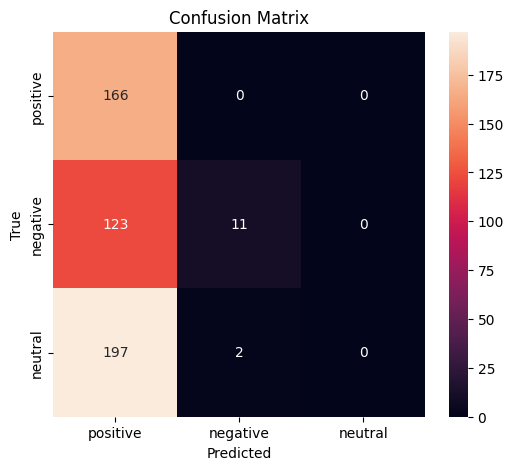

In [35]:
y_true = df['sentiment']
y_pred = df['prediction']

labels = ['positive', 'negative', 'neutral']

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

 positive [2762]
 negative [4016]
 neutral [9238]


In [39]:
text = df["text"].iloc[3]

prompt = f"{text} .The sentiment is"
print(prompt)
inputs = tokenizer(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits[0, -1]

print("positive:", logits[2762].item())
print("negative:", logits[4016].item())
print("neutral :", logits[9238].item())

We attend in the class just for listening teachers reading on slide. Just Nonsence   .The sentiment is
positive: 12.10757827758789
negative: 10.611356735229492
neutral : 10.014338493347168


In [37]:
df.head(20)

,Year,Month,Day,Time of Tweet,text,sentiment,Platform,prediction
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter,positive
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook,positive
2,2017,8,18,night,Don't angry me,negative,Facebook,negative
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook,positive
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram,positive
5,2016,11,22,night,"Its night 2 am, feeling neutral",neutral,Facebook,positive
6,2017,12,28,morning,2 am feedings for the baby are fun when he is ...,positive,Facebook,positive
7,2017,12,28,noon,Soooo high,neutral,Instagram,positive
8,2019,10,28,night,Both of you,neutral,Twitter,positive
9,2018,5,28,morning,Today first time I arrive in the boat. Its ama...,positive,Facebook,positive
